Topological Signature Analysis

  VP Wavelet (Gold Standard)
    Note: used as topological reference only (sigma=0 by construction)

  Kernel 3503 (Robust)
    sigma     = 0.978563
    L2 to VP  = 29.5466
    Wass to VP= 0.7938

  Kernel 2905 (Vulnerable)
    sigma     = 2.90e-07
    L2 to VP  = 29.7658
    Wass to VP= 12.0973


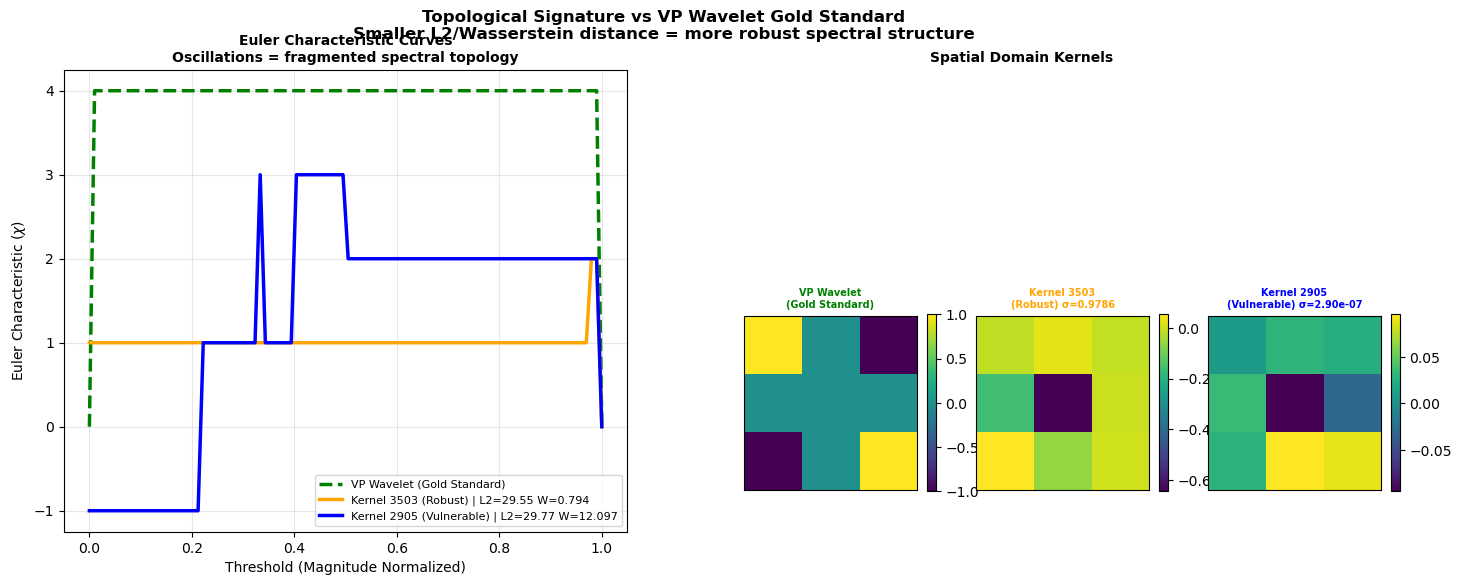

Saved: topological_signature.png

Computing L2 distances for all 4096 kernels...
  500/4096 done
  1000/4096 done
  1500/4096 done
  2000/4096 done
  2500/4096 done
  3000/4096 done
  3500/4096 done
  4000/4096 done


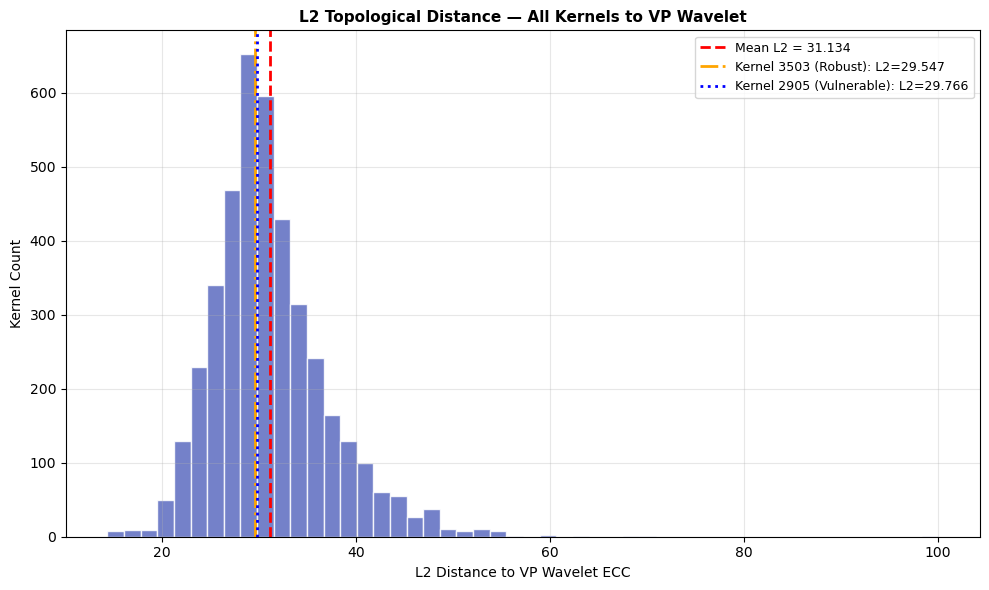

Saved: L2TopologicalDistance.png

  Mean L2:              31.1341
  Kernel 3503 L2:  29.5466
  Kernel 2905 L2: 29.7658


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sharedfunctions import (loadKernels, computeSigma, computeMagnitudeResponse,
                              calculateEcc, eccL2Distance, eccWassersteinDistance,
                              generateVPWaveletKernel,
                              IDXROBUST, IDXVULNERABLE, NTHRESH, CSVPATH)

# ============================================================
# Load kernels
# ============================================================
kernels = loadKernels(CSVPATH)

# ============================================================
# Compute magnitude responses and ECCs
# ============================================================
vp = generateVPWaveletKernel()
magVp = computeMagnitudeResponse(vp)
tSpace, eccVp = calculateEcc(magVp)

hRobust     = kernels[IDXROBUST]
hVulnerable = kernels[IDXVULNERABLE]

magRobust     = computeMagnitudeResponse(hRobust)
magVulnerable = computeMagnitudeResponse(hVulnerable)

_, eccRobust     = calculateEcc(magRobust)
_, eccVulnerable = calculateEcc(magVulnerable)

sigmaRobust     = computeSigma(hRobust)
sigmaVulnerable = computeSigma(hVulnerable)

l2Robust     = eccL2Distance(eccRobust,     eccVp)
l2Vulnerable = eccL2Distance(eccVulnerable, eccVp)
wassRobust     = eccWassersteinDistance(eccRobust,     eccVp)
wassVulnerable = eccWassersteinDistance(eccVulnerable, eccVp)

# ============================================================
# Print summary
# ============================================================
print("="*60)
print("Topological Signature Analysis")
print("="*60)
print(f"\n  VP Wavelet (Gold Standard)")
print(f"    Note: used as topological reference only (sigma=0 by construction)")
print(f"\n  Kernel {IDXROBUST} (Robust)")
print(f"    sigma     = {sigmaRobust:.6f}")
print(f"    L2 to VP  = {l2Robust:.4f}")
print(f"    Wass to VP= {wassRobust:.4f}")
print(f"\n  Kernel {IDXVULNERABLE} (Vulnerable)")
print(f"    sigma     = {sigmaVulnerable:.2e}")
print(f"    L2 to VP  = {l2Vulnerable:.4f}")
print(f"    Wass to VP= {wassVulnerable:.4f}")

# ============================================================
# Figure 1: ECC curves comparison
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Topological Signature vs VP Wavelet Gold Standard\n"
             "Smaller L2/Wasserstein distance = more robust spectral structure",
             fontsize=12, fontweight='bold')

# Left panel: ECC curves
ax = axes[0]
ax.plot(tSpace, eccVp, color='green', linewidth=2.5, linestyle='--',
        label='VP Wavelet (Gold Standard)')
ax.plot(tSpace, eccRobust, color='orange', linewidth=2.5,
        label=f'Kernel {IDXROBUST} (Robust) | '
              f'L2={l2Robust:.2f} W={wassRobust:.3f}')
ax.plot(tSpace, eccVulnerable, color='blue', linewidth=2.5,
        label=f'Kernel {IDXVULNERABLE} (Vulnerable) | '
              f'L2={l2Vulnerable:.2f} W={wassVulnerable:.3f}')
ax.set_title("Euler Characteristic Curves\n"
             "Oscillations = fragmented spectral topology",
             fontsize=10, fontweight='bold')
ax.set_xlabel("Threshold (Magnitude Normalized)", fontsize=10)
ax.set_ylabel("Euler Characteristic ($\\chi$)", fontsize=10)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Right panel: spatial kernels
ax = axes[1]
kernelData = [
    (vp,          'VP Wavelet\n(Gold Standard)', 'green'),
    (hRobust,     f'Kernel {IDXROBUST}\n(Robust) σ={sigmaRobust:.4f}', 'orange'),
    (hVulnerable, f'Kernel {IDXVULNERABLE}\n(Vulnerable) σ={sigmaVulnerable:.2e}', 'blue'),
]
for i, (h, label, color) in enumerate(kernelData):
    ax_inset = fig.add_axes([0.55 + i*0.145, 0.15, 0.12, 0.35])
    im = ax_inset.imshow(h, cmap='viridis')
    ax_inset.set_title(label, fontsize=7, color=color, fontweight='bold')
    ax_inset.set_xticks([])
    ax_inset.set_yticks([])
    plt.colorbar(im, ax=ax_inset, fraction=0.046)
ax.axis('off')
ax.set_title("Spatial Domain Kernels", fontsize=10, fontweight='bold')

plt.savefig("topological_signature.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: topological_signature.png")

# ============================================================
# Figure 2: Full population L2 distance distribution
# ============================================================
print("\nComputing L2 distances for all 4096 kernels...")
allL2 = []
for i, h in enumerate(kernels):
    mag = computeMagnitudeResponse(h)
    _, ecc = calculateEcc(mag)
    allL2.append(eccL2Distance(ecc, eccVp))
    if (i + 1) % 500 == 0:
        print(f"  {i+1}/4096 done")
allL2 = np.array(allL2)

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(allL2, bins=50, color='#5c6bc0', edgecolor='white', alpha=0.85)
ax.axvline(np.mean(allL2), color='red', linewidth=2, linestyle='--',
           label=f'Mean L2 = {np.mean(allL2):.3f}')
ax.axvline(allL2[IDXROBUST], color='orange', linewidth=2, linestyle='-.',
           label=f'Kernel {IDXROBUST} (Robust): L2={allL2[IDXROBUST]:.3f}')
ax.axvline(allL2[IDXVULNERABLE], color='blue', linewidth=2, linestyle=':',
           label=f'Kernel {IDXVULNERABLE} (Vulnerable): L2={allL2[IDXVULNERABLE]:.3f}')
ax.set_title("L2 Topological Distance — All Kernels to VP Wavelet",
             fontsize=11, fontweight='bold')
ax.set_xlabel("L2 Distance to VP Wavelet ECC", fontsize=10)
ax.set_ylabel("Kernel Count", fontsize=10)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("L2TopologicalDistance.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: L2TopologicalDistance.png")
print(f"\n  Mean L2:              {np.mean(allL2):.4f}")
print(f"  Kernel {IDXROBUST} L2:  {allL2[IDXROBUST]:.4f}")
print(f"  Kernel {IDXVULNERABLE} L2: {allL2[IDXVULNERABLE]:.4f}")